# Snippet to take a look at commodities data availability through yfinance

In [33]:
# Import packages

import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt

In [35]:
# Output directory

OUTPUT_DIR = Path(
    r"C:\Users\pcarg\OneDrive\Υπολογιστής\MFE UCLA\Projects\Commodities\Data"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Commodities universe

commodities = {

    # =====================================================
    # ENERGY
    # =====================================================

    "WTI Crude": "CL=F",
    "Brent": "BZ=F",
    "Natural Gas": "NG=F",
    "RBOB": "RB=F",
    "HeatingOil": "HO=F",

    # =====================================================
    # PRECIOUS METALS
    # =====================================================

    "Gold": "GC=F",
    "Silver": "SI=F",
    "Platinum": "PL=F",
    "Palladium": "PA=F",

    # =====================================================
    # INDUSTRIAL METALS
    # =====================================================

    "Copper": "HG=F",

    # =====================================================
    # GRAINS
    # =====================================================

    "Corn": "ZC=F",
    "Soybeans": "ZS=F",
    "Wheat": "ZW=F",
    "KC_Wheat": "KE=F",
    "Rice": "ZR=F",
    "Oats": "ZO=F",

    # =====================================================
    # SOFTS
    # =====================================================

    "Coffee": "KC=F",
    "Sugar": "SB=F",
    "Cocoa": "CC=F",
    "Cotton": "CT=F",
    "OrangeJuice": "OJ=F",

    # =====================================================
    # LIVESTOCK
    # =====================================================

    "LiveCattle": "LE=F",
    "LeanHogs": "HE=F",
    "FeederCattle": "GF=F"
}

In [ ]:
# Other futures universe

futures = {

    # =====================================================
    # EQUITY INDEX
    # =====================================================

    "SP500": "ES=F",
    "Nasdaq100": "NQ=F",
    "Dow": "YM=F",
    "Russell2000": "RTY=F",

    # =====================================================
    # RATES
    # =====================================================

    "US_2Y": "ZT=F",
    "US_5Y": "ZF=F",
    "US_10Y": "ZN=F",
    "US_30Y": "ZB=F",
    "UltraBond": "UB=F",

    # SOFR (SR3) intentionally excluded here - no usable Yahoo continuous
    # ticker exists. SR3=F/SR1=F both resolve but return only 1 row (today),
    # not a real history - checked 2026-07-20, not assumed. SOFR still has
    # real term-structure coverage via jobs/capture_term_structure.py +
    # Databento (see WORKFLOW.md Phase 4); it's just not in this core panel.

    # =====================================================
    # FX
    # =====================================================

    "EURUSD": "6E=F",
    "JPYUSD": "6J=F",
    "GBPUSD": "6B=F",
    "AUDUSD": "6A=F",
    "CADUSD": "6C=F",
    "SwissFranc": "6S=F",
    "MexicanPeso": "6M=F",

    # =====================================================
    # LUMBER (no natural sector - its own category, per DATA_SCHEMA.md)
    # =====================================================

    "Lumber": "LBR=F"
}

In [7]:
# Combine into master

universe = {
    **commodities,
    **futures
}

print(f"Number of assets: {len(universe)}")

Number of assets: 38


In [9]:
# Audit yahoo coverage

audit = []

for asset, ticker in universe.items():

    try:

        df = yf.download(
            ticker,
            period="max",
            auto_adjust=False,
            progress=False
        )

        audit.append({
            "Asset": asset,
            "Ticker": ticker,
            "Rows": len(df),
            "Start": df.index.min(),
            "End": df.index.max()
        })

    except Exception:

        audit.append({
            "Asset": asset,
            "Ticker": ticker,
            "Rows": 0,
            "Start": None,
            "End": None
        })

audit = pd.DataFrame(audit)

audit.sort_values(
    "Rows",
    ascending=False
)

,Asset,Ticker,Rows,Start,End
14,Rice,ZR=F,6700,1999-09-14,2026-06-07
19,Cotton,CT=F,6627,2000-01-03,2026-06-05
18,Cocoa,CC=F,6627,2000-01-03,2026-06-05
16,Coffee,KC=F,6625,2000-01-03,2026-06-05
17,Sugar,SB=F,6588,2000-03-01,2026-06-05
15,Oats,ZO=F,6557,1999-09-14,2026-06-07
28,US_2Y,ZT=F,6522,2000-06-02,2026-06-07
37,CADUSD,6C=F,6516,2000-05-23,2026-06-07
8,Palladium,PA=F,6505,1998-09-28,2026-06-07
33,EURUSD,6E=F,6496,2000-09-12,2026-06-07


In [11]:
# Inspect failed assets

audit[audit["Rows"] == 0]

,Asset,Ticker,Rows,Start,End


In [13]:
# Generate container dataframes

open_prices = pd.DataFrame()
high_prices = pd.DataFrame()
low_prices = pd.DataFrame()
close_prices = pd.DataFrame()
adj_close_prices = pd.DataFrame()
volumes = pd.DataFrame()

metadata = []

In [15]:
# Download production dataset

for asset, ticker in universe.items():

    print(f"Downloading {asset} ({ticker})")

    try:

        df = yf.download(
            ticker,
            period="max",
            auto_adjust=False,
            progress=False
        )

        if len(df) == 0:
            continue

        open_prices[asset] = df["Open"]
        high_prices[asset] = df["High"]
        low_prices[asset] = df["Low"]
        close_prices[asset] = df["Close"]
        adj_close_prices[asset] = df["Adj Close"]
        volumes[asset] = df["Volume"]

        metadata.append({
            "Asset": asset,
            "Ticker": ticker,
            "Rows": len(df),
            "Start": df.index.min(),
            "End": df.index.max()
        })

    except Exception as e:

        print(
            f"FAILED -> {asset} ({ticker})"
        )

        print(e)

In [17]:
# Sort index

datasets = [
    open_prices,
    high_prices,
    low_prices,
    close_prices,
    adj_close_prices,
    volumes
]

for df in datasets:

    df.sort_index(inplace=True)

    df.index.name = "Date"

In [19]:
# Metadata

metadata = pd.DataFrame(metadata)

metadata.sort_values(
    "Rows",
    ascending=False
)

,Asset,Ticker,Rows,Start,End
14,Rice,ZR=F,6700,1999-09-14,2026-06-07
19,Cotton,CT=F,6627,2000-01-03,2026-06-05
18,Cocoa,CC=F,6627,2000-01-03,2026-06-05
16,Coffee,KC=F,6625,2000-01-03,2026-06-05
17,Sugar,SB=F,6588,2000-03-01,2026-06-05
15,Oats,ZO=F,6557,1999-09-14,2026-06-07
28,US_2Y,ZT=F,6522,2000-06-02,2026-06-07
37,CADUSD,6C=F,6516,2000-05-23,2026-06-07
8,Palladium,PA=F,6505,1998-09-28,2026-06-07
33,EURUSD,6E=F,6496,2000-09-12,2026-06-07


In [21]:
# Diagnostics for missing data

missing_summary = pd.DataFrame({
    "Missing Count":
        close_prices.isna().sum(),

    "Missing %":
        100 * close_prices.isna().mean()
})

missing_summary.sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
Russell2000,4232,65.359073
UltraBond,2350,36.293436
Brent,1783,27.536680
Platinum,687,10.610039
Palladium,448,6.918919
Dow,402,6.208494
OrangeJuice,274,4.231660
FeederCattle,189,2.918919
Oats,175,2.702703
LiveCattle,158,2.440154


In [23]:
# Start dates

start_dates = pd.DataFrame({
    "First Observation":
        close_prices.apply(
            lambda x: x.first_valid_index()
        )
})

start_dates.sort_values(
    "First Observation"
)

,First Observation
WTI Crude,2000-08-23
US_2Y,2000-08-23
Cotton,2000-08-23
Sugar,2000-08-23
Coffee,2000-08-23
Oats,2000-08-23
Rice,2000-08-23
Wheat,2000-08-23
Corn,2000-08-23
Cocoa,2000-08-23


In [25]:
# End dates

end_dates = pd.DataFrame({
    "Last Observation":
        close_prices.apply(
            lambda x: x.last_valid_index()
        )
})

end_dates.sort_values(
    "Last Observation"
)

,Last Observation
Cocoa,2026-06-05
Sugar,2026-06-05
Coffee,2026-06-05
LiveCattle,2026-06-05
LeanHogs,2026-06-05
FeederCattle,2026-06-05
OrangeJuice,2026-06-05
Cotton,2026-06-05
US_2Y,2026-06-07
US_10Y,2026-06-07


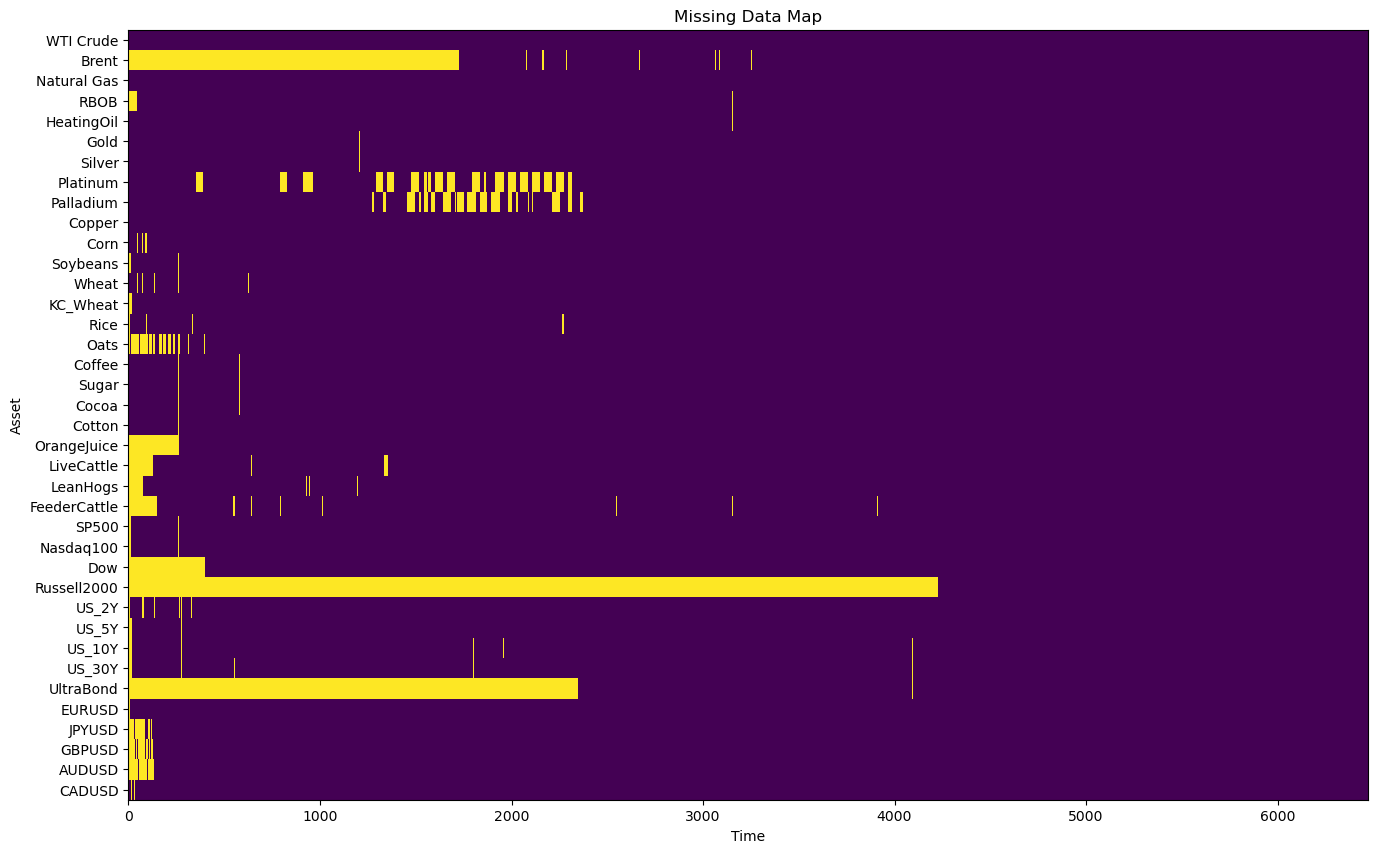

In [31]:
# Heatmap for missingness

plt.figure(figsize=(16,10))

plt.imshow(
    close_prices.isna().T,
    aspect="auto",
    interpolation="none"
)

plt.yticks(
    range(len(close_prices.columns)),
    close_prices.columns
)

plt.xlabel("Time")
plt.ylabel("Asset")

plt.title(
    "Missing Data Map"
)

plt.show()

In [37]:
# Save files

open_prices.to_parquet(
    OUTPUT_DIR / "open.parquet"
)

high_prices.to_parquet(
    OUTPUT_DIR / "high.parquet"
)

low_prices.to_parquet(
    OUTPUT_DIR / "low.parquet"
)

close_prices.to_parquet(
    OUTPUT_DIR / "close.parquet"
)

adj_close_prices.to_parquet(
    OUTPUT_DIR / "adj_close.parquet"
)

volumes.to_parquet(
    OUTPUT_DIR / "volume.parquet"
)


# Metadata

metadata.to_csv(
    OUTPUT_DIR / "metadata.csv",
    index=False
)

In [ ]:
# Final check

audit.to_csv(
    OUTPUT_DIR / "audit.csv",
    index=False
)

print(f"Files saved to:\n{OUTPUT_DIR}")